In [5]:
kaggle = ''

In [7]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9 -p ./data/handwritten_digits --unzip

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0




  0%|          | 0.00/66.7M [00:00<?, ?B/s]
  1%|▏         | 1.00M/66.7M [00:00<00:56, 1.22MB/s]
  3%|▎         | 2.00M/66.7M [00:00<00:27, 2.45MB/s]
  6%|▌         | 4.00M/66.7M [00:01<00:13, 4.90MB/s]
  9%|▉         | 6.00M/66.7M [00:01<00:09, 7.04MB/s]
 12%|█▏        | 8.00M/66.7M [00:01<00:07, 8.71MB/s]
 15%|█▍        | 10.0M/66.7M [00:01<00:05, 10.2MB/s]
 18%|█▊        | 12.0M/66.7M [00:01<00:05, 11.5MB/s]
 21%|██        | 14.0M/66.7M [00:01<00:04, 12.3MB/s]
 24%|██▍       | 16.0M/66.7M [00:02<00:04, 13.2MB/s]
 27%|██▋       | 18.0M/66.7M [00:02<00:03, 13.8MB/s]
 30%|██▉       | 20.0M/66.7M [00:02<00:03, 14.3MB/s]
 33%|███▎      | 22.0M/66.7M [00:02<00:03, 14.5MB/s]
 36%|███▌      | 24.0M/66.7M [00:02<00:03, 14.8MB/s]
 39%|███▉      | 26.0M/66.7M [00:02<00:02, 16.1MB/s]
 42%|████▏     | 28.0M/66.7M [00:02<00:02, 16.8MB/s]
 45%|████▍     | 30.0M/66.7M [00:02<00:02, 17.8MB/s]
 48%|████▊     | 32.0M/66.7M [00:02<00:01, 18.6MB/s]
 51%|█████     | 34.0M/66.7M [00:03<00:01, 18.5MB/s]
 

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

print(tf.__version__)


2.20.0


In [9]:
# Membuat dataset gambar dari folder hasil download Kaggle

data_dir = "./data/handwritten_digits"
img_height, img_width = 90, 140
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Kelas:", class_names)

Found 21555 files belonging to 10 classes.
Using 17244 files for training.
Found 21555 files belonging to 10 classes.
Using 4311 files for validation.
Kelas: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [10]:
# Optimasi pipeline data (opsional tapi disarankan)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

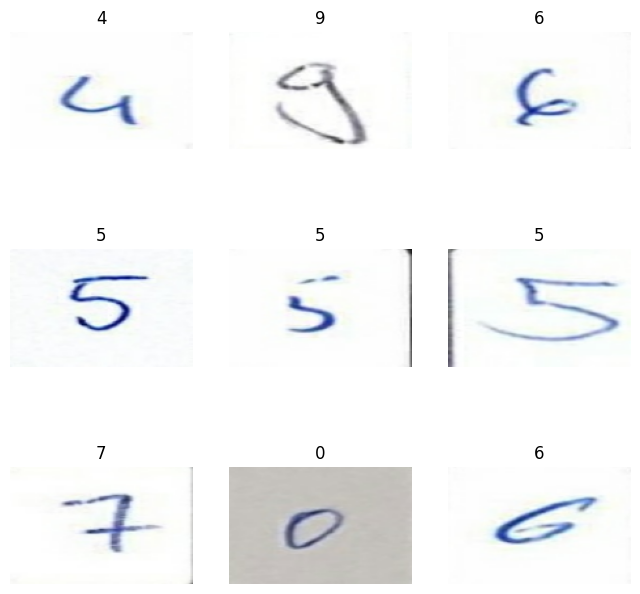

In [11]:
# Contoh menampilkan beberapa gambar dan labelnya
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
    break
plt.show()

In [12]:
# Membangun model Artificial Neural Network (MLP) untuk klasifikasi 0-9

num_classes = 10

model = models.Sequential()

# Layer input: citra 90x140 RGB, di-rescale 0-1
model.add(layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)))

# Flatten agar menjadi vektor 1D (seperti fitur tabular pada Titanic)
model.add(layers.Flatten())

# Hidden layers MLP
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.3))

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.3))

# Output layer: 10 kelas (0–9) dengan softmax
model.add(layers.Dense(num_classes, activation='softmax'))

model.summary()

d:\Code\college-task\machine-learning-task\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 90, 140, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 37800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,677,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,711,242 (37.05 MB)

 Trainable params: 9,711,242 (37.05 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Compile model MLP untuk multi-kelas
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # label berupa integer 0–9
    metrics=['accuracy']
)

In [14]:
# Early stopping seperti pada kasus Titanic
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [15]:
# Training model MLP pada dataset citra
history = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
539/539 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.1039 - loss: 2.9485 - val_accuracy: 0.1072 - val_loss: 2.3029
Epoch 2/30
539/539 ━━━━━━━━━━━━━━━━━━━━ 30s 55ms/step - accuracy: 0.1034 - loss: 2.3092 - val_accuracy: 0.0977 - val_loss: 2.3033
Epoch 3/30
539/539 ━━━━━━━━━━━━━━━━━━━━ 35s 65ms/step - accuracy: 0.1039 - loss: 2.3020 - val_accuracy: 0.0977 - val_loss: 2.3034
Epoch 4/30
539/539 ━━━━━━━━━━━━━━━━━━━━ 34s 63ms/step - accuracy: 0.1055 - loss: 2.3020 - val_accuracy: 0.0977 - val_loss: 2.3036
Epoch 5/30
539/539 ━━━━━━━━━━━━━━━━━━━━ 34s 63ms/step - accuracy: 0.1055 - loss: 2.3020 - val_accuracy: 0.0977 - val_loss: 2.3036
Epoch 6/30
539/539 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - accuracy: 0.1043 - loss: 2.3020 - val_accuracy: 0.0977 - val_loss: 2.3035


In [16]:
# Evaluasi performa model pada validation set
val_loss, val_accuracy = model.evaluate(val_ds)

print(f'Validation Loss: {val_loss:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')

135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.1072 - loss: 2.3029
Validation Loss: 2.3029
Validation Accuracy: 0.1072


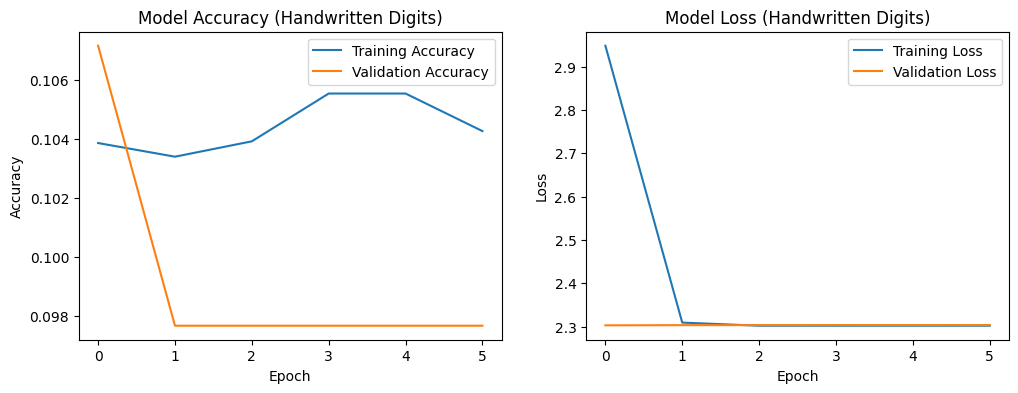

In [17]:
# Plot akurasi dan loss seperti pada kasus Titanic
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy (Handwritten Digits)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (Handwritten Digits)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()